In [9]:
# ============================================
# F8 - Week 05 Black-Box Optimisation Pipeline
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# Goal: MAXIMISE y
# X: (n, 8) in [0, 1]
# y: (n,)
# ============================================

# -----------------------------
# 0) Imports
# -----------------------------
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Reproducibility
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

In [10]:
# =============================
# 0) CONFIG
# =============================
# Your required paths:
INPUTS_PATH = "data/F8/initial_inputs.npy"
OUTPUTS_PATH = "data/F8/initial_outputs.npy"

# Fallback (useful in some environments, incl. this sandbox)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Bounds
D = 8
LB = np.zeros(D)
UB = np.ones(D)

# Acquisition (UCB): larger kappa = more exploration
KAPPA = 1.5

# Candidate generation sizes
N_GLOBAL = 6000
N_LOCAL = 3000
N_BIASED = 3000

# Local sampling radius (smaller = more exploitation)
LOCAL_SIGMA = 0.08  # in [0,1] space

# Surrogate hyperparams (reasonable defaults for week-to-week)
RF_N_ESTIMATORS = 600
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = "sqrt"

GBM_ENSEMBLE_SEEDS = [0, 1, 2, 3, 4, 5]  # ensemble members
GBM_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    random_state=None
)

# Duplicate filtering tolerance
DUP_TOL = 1e-10



In [11]:
# =============================
# 1) LOAD
# =============================
def load_npy_with_fallback(primary_path: str, fallback_path: str):
    if os.path.exists(primary_path):
        return np.load(primary_path)
    if os.path.exists(fallback_path):
        return np.load(fallback_path)
    raise FileNotFoundError(f"Could not find {primary_path} or {fallback_path}")

X = load_npy_with_fallback(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y = load_npy_with_fallback(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

# Basic checks
assert X.ndim == 2 and X.shape[1] == D, f"Expected X shape (n, {D}), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,), got {y.shape}"

# Clip just in case (should already be in bounds)
X = np.clip(X, LB, UB)

n = X.shape[0]
best_idx = int(np.argmax(y))
x_best = X[best_idx].copy()
y_best = float(y[best_idx])

print(f"Loaded dataset: n={n}, D={D}")
print(f"Best observed y so far: {y_best:.6f} at index {best_idx}")
print("x_best =", np.array2string(x_best, precision=6, separator=", "))



Loaded dataset: n=44, D=8
Best observed y so far: 9.897423 at index 43
x_best = [0.201507, 0.280888, 0.150852, 0.061778, 1.      , 0.64205 , 0.138749,
 0.884062]


In [12]:
# =============================
# 2) SURROGATE
# =============================
# ---- 3.1 Gaussian Process (with scaling)
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=np.ones(D), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=GLOBAL_SEED,
    n_restarts_optimizer=5
)
gp.fit(Xz, y)

# ---- 3.2 Random Forest
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    random_state=GLOBAL_SEED,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES,
    n_jobs=-1
)
rf.fit(X, y)

# ---- 3.3 GBM ensemble (different seeds)
gbm_ensemble = []
for s in GBM_ENSEMBLE_SEEDS:
    m = GradientBoostingRegressor(**{**GBM_PARAMS, "random_state": s})
    m.fit(X, y)
    gbm_ensemble.append(m)

# ---- Utility: predict mean + uncertainty per-model
def gp_predict_mean_std(Xcand):
    Xcand_z = scaler.transform(Xcand)
    mu, std = gp.predict(Xcand_z, return_std=True)
    return mu, std

def rf_predict_mean_std(Xcand):
    # mean across trees; std across tree predictions
    tree_preds = np.vstack([t.predict(Xcand) for t in rf.estimators_])  # (n_trees, n_cand)
    mu = tree_preds.mean(axis=0)
    std = tree_preds.std(axis=0, ddof=0)
    return mu, std

def gbm_predict_mean_std(Xcand):
    preds = np.vstack([m.predict(Xcand) for m in gbm_ensemble])  # (n_members, n_cand)
    mu = preds.mean(axis=0)
    std = preds.std(axis=0, ddof=0)
    return mu, std

# ---- Ensemble fuse (mean + conservative uncertainty)
def ensemble_predict_mean_std(Xcand):
    mu_gp, std_gp = gp_predict_mean_std(Xcand)
    mu_rf, std_rf = rf_predict_mean_std(Xcand)
    mu_gb, std_gb = gbm_predict_mean_std(Xcand)

    # Model means (stacked)
    mus = np.vstack([mu_gp, mu_rf, mu_gb])  # (3, n_cand)

    # Within-model variances
    vars_within = np.vstack([std_gp**2, std_rf**2, std_gb**2])  # (3, n_cand)
    var_within_mean = vars_within.mean(axis=0)

    # Between-model disagreement (variance of model means)
    var_between = mus.var(axis=0, ddof=0)

    # Final
    mu = mus.mean(axis=0)
    std = np.sqrt(var_within_mean + var_between)
    return mu, std, (mu_gp, std_gp, mu_rf, std_rf, mu_gb, std_gb)

# Quick in-sample sanity check (not a true CV, but good for diagnostics)
mu_train, std_train, _ = ensemble_predict_mean_std(X)
r2 = r2_score(y, mu_train)
rmse = np.sqrt(mean_squared_error(y, mu_train))
print(f"Ensemble in-sample: R2={r2:.4f}, RMSE={rmse:.4f}")


Ensemble in-sample: R2=0.9954, RMSE=0.0698


In [13]:
# =============================
# 3) ACQUISITION
# =============================
def ucb(mu, std, kappa=1.5):
    return mu + kappa * std

# ---- 4.1 Candidate generators
def sample_global(n_points):
    return rng.uniform(LB, UB, size=(n_points, D))

def sample_local_around_best(n_points, center, sigma=0.08):
    Xcand = center + rng.normal(0.0, sigma, size=(n_points, D))
    return np.clip(Xcand, LB, UB)

def sample_importance_biased(n_points, center, importances):
    """
    Bias dominant dimensions upward while keeping others near center.
    importances: array shape (D,), nonnegative.
    """
    imp = np.maximum(importances, 0)
    if imp.sum() <= 0:
        return sample_local_around_best(n_points, center, sigma=LOCAL_SIGMA)

    w = imp / imp.sum()

    # Choose top dims
    topk = min(3, D)
    top_dims = np.argsort(w)[::-1][:topk]

    Xcand = np.tile(center, (n_points, 1))

    # For top dims: sample skewed toward higher values (Beta distribution)
    # For others: small noise around center
    for j in range(D):
        if j in top_dims:
            a, b = 3.0, 1.5  # skew toward 1
            Xcand[:, j] = rng.beta(a, b, size=n_points)
        else:
            Xcand[:, j] = Xcand[:, j] + rng.normal(0.0, 0.03, size=n_points)

    return np.clip(Xcand, LB, UB)

# ---- 4.2 Feature importances (RF + GBM mean) for biased sampling
rf_imp = getattr(rf, "feature_importances_", np.ones(D)/D)

gbm_imps = []
for m in gbm_ensemble:
    gbm_imps.append(getattr(m, "feature_importances_", np.ones(D)/D))
gbm_imp = np.mean(np.vstack(gbm_imps), axis=0)

combo_imp = 0.5 * rf_imp + 0.5 * gbm_imp
combo_imp = combo_imp / (combo_imp.sum() + 1e-12)

# ---- 4.3 Build candidate pool
X_global = sample_global(N_GLOBAL)
X_local = sample_local_around_best(N_LOCAL, x_best, sigma=LOCAL_SIGMA)
X_biased = sample_importance_biased(N_BIASED, x_best, combo_imp)

X_cand = np.vstack([X_global, X_local, X_biased])
X_cand = np.clip(X_cand, LB, UB)

# ---- Remove candidates that are (almost) duplicates of existing X
# Using a simple tolerance-based filter via rounding (fast and good enough here)
decimals = 10
X_existing_key = set(map(tuple, np.round(X, decimals=decimals)))
mask_new = []
for row in np.round(X_cand, decimals=decimals):
    mask_new.append(tuple(row) not in X_existing_key)
mask_new = np.array(mask_new, dtype=bool)
X_cand = X_cand[mask_new]

print(f"Candidate pool after removing duplicates: {X_cand.shape[0]} points")

# ---- Score by UCB
mu_c, std_c, _ = ensemble_predict_mean_std(X_cand)
acq = ucb(mu_c, std_c, kappa=KAPPA)
best_cand_idx = int(np.argmax(acq))
x_next = X_cand[best_cand_idx].copy()

print("\nSelected next point by UCB:")
print("x_next =", np.array2string(x_next, precision=6, separator=", "))
print(f"Predicted mean={mu_c[best_cand_idx]:.6f}, std={std_c[best_cand_idx]:.6f}, UCB={acq[best_cand_idx]:.6f}")



Candidate pool after removing duplicates: 12000 points

Selected next point by UCB:
x_next = [0.255161, 0.304708, 0.090349, 0.180899, 1.      , 0.528123, 0.21434 ,
 0.830249]
Predicted mean=9.629752, std=0.605760, UCB=10.538392


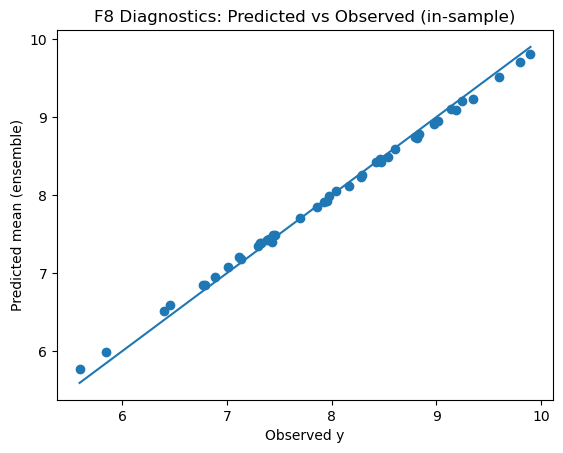

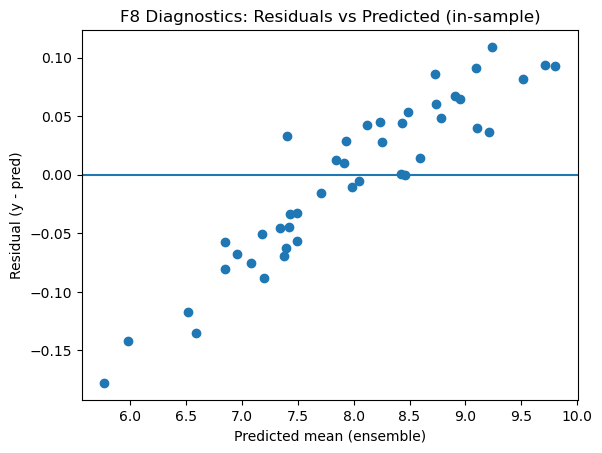

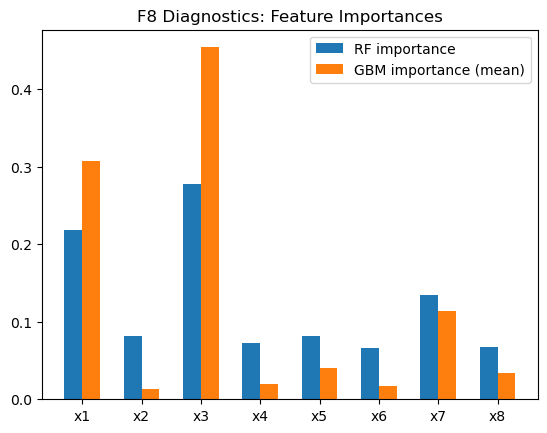

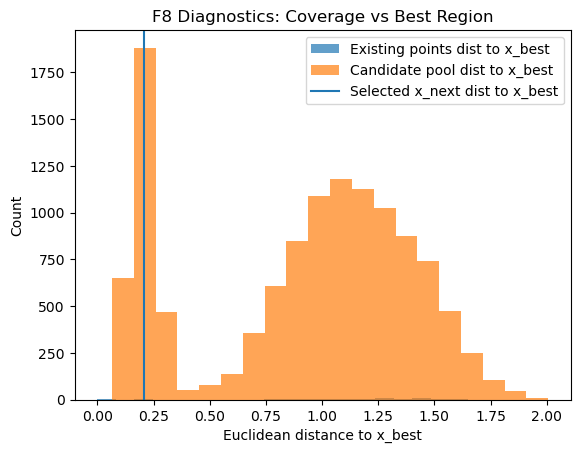

In [14]:
# =============================
# 4) DIAGNOSTICS
# =============================
# 5.1 Predicted vs Observed (in-sample)
plt.figure()
plt.scatter(y, mu_train)
mn = min(y.min(), mu_train.min())
mx = max(y.max(), mu_train.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed y")
plt.ylabel("Predicted mean (ensemble)")
plt.title("F8 Diagnostics: Predicted vs Observed (in-sample)")
plt.show()

# 5.2 Residuals vs Predicted
resid = y - mu_train
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0.0)
plt.xlabel("Predicted mean (ensemble)")
plt.ylabel("Residual (y - pred)")
plt.title("F8 Diagnostics: Residuals vs Predicted (in-sample)")
plt.show()

# 5.3 Feature importances (RF + GBM)
plt.figure()
xpos = np.arange(D)
plt.bar(xpos - 0.15, rf_imp, width=0.3, label="RF importance")
plt.bar(xpos + 0.15, gbm_imp, width=0.3, label="GBM importance (mean)")
plt.xticks(xpos, [f"x{i+1}" for i in range(D)])
plt.title("F8 Diagnostics: Feature Importances")
plt.legend()
plt.show()

# 5.4 Coverage / "not stuck in one region"
# Compare distances from x_best for existing data and candidates
dist_existing = np.linalg.norm(X - x_best, axis=1)
dist_candidates = np.linalg.norm(X_cand - x_best, axis=1)

plt.figure()
plt.hist(dist_existing, bins=20, alpha=0.7, label="Existing points dist to x_best")
plt.hist(dist_candidates, bins=20, alpha=0.7, label="Candidate pool dist to x_best")
plt.axvline(np.linalg.norm(x_next - x_best), label="Selected x_next dist to x_best")
plt.xlabel("Euclidean distance to x_best")
plt.ylabel("Count")
plt.title("F8 Diagnostics: Coverage vs Best Region")
plt.legend()
plt.show()


In [15]:
# =============================
# 5) OUTPUT
# =============================
# One line of values to submit
print("\n" + "="*60)
print("SUBMISSION (one line, 8 values):")
print(" ".join([f"{v:.8f}" for v in x_next]))
print("="*60)

# Optional: save for your workflow
# np.save("data/F8/next_x_week05.npy", x_next)


SUBMISSION (one line, 8 values):
0.25516059 0.30470820 0.09034884 0.18089940 1.00000000 0.52812282 0.21434050 0.83024944
